# Chapter 4: Regression and Prediction

## Practical Statistics for Data Scientists

Penulis:
Peter Bruce, Andrew Bruce, Peter Gedeck


## Pendahuluan

Regression merupakan metode statistik yang digunakan untuk memahami
hubungan antara variabel prediktor dan variabel respon.

Dalam data science, regression digunakan untuk:

- menjelaskan hubungan antar variabel,
- melakukan prediksi,
- mengetahui faktor yang berpengaruh terhadap suatu hasil.


Chapter ini membahas:

1. Simple Linear Regression
2. Multiple Linear Regression
3. Model Assessment
4. Variable Selection
5. Regression Diagnostics
6. Polynomial Regression
7. Spline Regression
8. Generalized Additive Models

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import statsmodels.api as sm
import statsmodels.formula.api as smf


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


from sklearn.linear_model import LinearRegression

# Simple Linear Regression

Simple Linear Regression digunakan untuk mengetahui hubungan antara
satu variabel prediktor (X) dengan satu variabel respon (Y).

Persamaan regresi:

Y = β0 + β1X + ε


Keterangan:

Y  = variabel respon

X  = variabel prediktor

β0 = intercept

β1 = koefisien regresi

ε  = error

In [3]:
lung = pd.read_csv(
    "data/LungDisease.csv"
)

lung.head()

,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


In [4]:
lung.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   PEFR      122 non-null    int64
 1   Exposure  122 non-null    int64
dtypes: int64(2)
memory usage: 2.0 KB


In [5]:
lung.describe()

,PEFR,Exposure
count,122.000000,122.000000
mean,365.655738,14.081967
std,105.132641,6.959850
min,110.000000,0.000000
25%,300.000000,7.000000
50%,365.000000,17.000000
75%,430.000000,20.000000
max,610.000000,23.000000


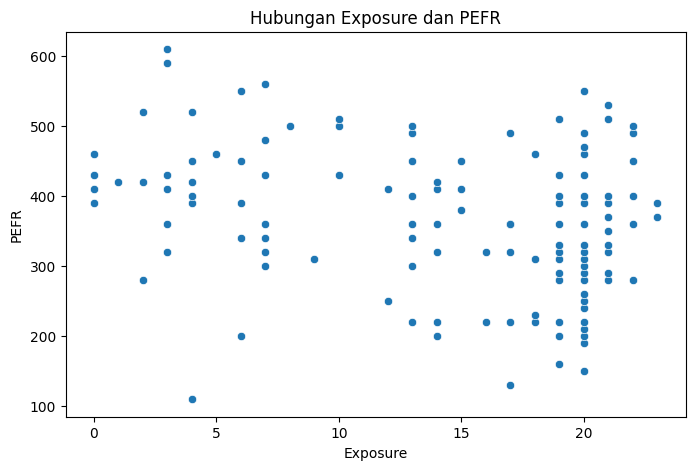

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=lung,
    x="Exposure",
    y="PEFR"
)


plt.title(
    "Hubungan Exposure dan PEFR"
)

plt.show()

In [7]:
lung_model = smf.ols(
    "PEFR ~ Exposure",
    data=lung
).fit()


lung_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   PEFR   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     9.974
Date:                Sun, 27 Sep 2026   Prob (F-statistic):            0.00201
Time:                        20:29:42   Log-Likelihood:                -735.68
No. Observations:                 122   AIC:                             1475.
Df Residuals:                     120   BIC:                             1481.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    424.5828     20.796     20.417      0.000     383.408     465.757
Exposure      -4.1846      1.325     -3.158      0.002      -6.808      -1.561
==============================================================================
Omnibus:                        0.767   Durbin-Watson:                   1.111
Prob(Omnibus):                  0.681   Jarque-Bera (JB):                0.891
Skew:                          -0.162   Prob(JB):                        0.641
Kurtosis:                       2.734   Cond. No.                         35.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
lung_model.params

Intercept    424.582807
Exposure      -4.184576
dtype: float64

## Interpretasi

Koefisien regresi menunjukkan perubahan nilai PEFR akibat perubahan
Exposure.

Jika koefisien Exposure bernilai positif, peningkatan Exposure
berhubungan dengan peningkatan PEFR.

Model regresi digunakan untuk memperkirakan nilai PEFR berdasarkan
nilai Exposure.

# Fitted Values dan Residual

Dalam regresi terdapat dua komponen penting:

Fitted Value:

Nilai prediksi yang dihasilkan model.


Residual:

Perbedaan antara nilai aktual dan nilai prediksi.

Residual = Aktual - Prediksi

In [9]:
lung["Prediction"] = lung_model.predict(
    lung
)


lung["Residual"] = (
    lung["PEFR"]
    -
    lung["Prediction"]
)


lung.head()

,PEFR,Exposure,Prediction,Residual
0,390,0,424.582807,-34.582807
1,410,0,424.582807,-14.582807
2,430,0,424.582807,5.417193
3,460,0,424.582807,35.417193
4,420,1,420.398230,-0.398230


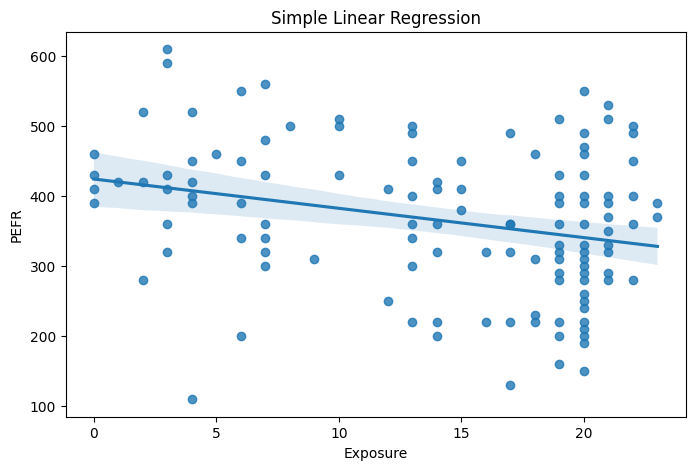

In [10]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=lung,
    x="Exposure",
    y="PEFR"
)

plt.title(
    "Simple Linear Regression"
)

plt.show()

# Multiple Linear Regression

Multiple regression menggunakan beberapa variabel prediktor untuk
menjelaskan satu variabel respon.

Model:

Y = β0 + β1X1 + β2X2 + ... + βnXn


Keuntungan:

- mampu mempertimbangkan beberapa faktor sekaligus,
- meningkatkan kemampuan prediksi.

In [12]:
kc_house = pd.read_csv(
    "data/house_sales.csv",
    sep="\t"
)

kc_house.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


In [13]:
house_model = smf.ols(
    """
    AdjSalePrice ~
    SqFtTotLiving
    + SqFtLot
    + Bathrooms
    + Bedrooms
    + BldgGrade
    """,
    data=kc_house
).fit()


house_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:35:21   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -5.219e+05   1.57e+04    -33.342      0.000   -5.53e+05   -4.91e+05
SqFtTotLiving   228.8306      3.899     58.694      0.000     221.189     236.472
SqFtLot          -0.0605      0.061     -0.988      0.323      -0.180       0.059
Bathrooms     -1.944e+04   3625.388     -5.363      0.000   -2.65e+04   -1.23e+04
Bedrooms      -4.777e+04   2489.732    -19.187      0.000   -5.27e+04   -4.29e+04
BldgGrade      1.061e+05   2396.445     44.277      0.000    1.01e+05    1.11e+05
==============================================================================
Omnibus:                    29676.557   Durbin-Watson:                   1.247
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         19390738.346
Skew:                           6.889   Prob(JB):                         0.00
Kurtosis:                     145.559   Cond. No.                     2.86e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Evaluasi Model

Model regresi perlu dievaluasi untuk mengetahui kemampuan model
dalam menjelaskan data.

Ukuran evaluasi:

1. R-squared

Menunjukkan proporsi variasi data yang dapat dijelaskan model.


2. RMSE

Mengukur rata-rata kesalahan prediksi.

In [14]:
house_model.rsquared

0.5405875253381901

In [15]:
prediction = house_model.predict(
    kc_house
)


rmse = np.sqrt(
    np.mean(
        (kc_house["AdjSalePrice"] - prediction)**2
    )
)


rmse

261220.19743696268

# Cross Validation

Cross validation digunakan untuk mengetahui kemampuan model pada
data yang belum pernah dilihat sebelumnya.

Data dibagi menjadi:

- Training set
- Testing set

In [16]:
train, test = train_test_split(
    kc_house,
    test_size=0.2,
    random_state=42
)


cv_model = smf.ols(
    """
    AdjSalePrice ~
    SqFtTotLiving
    + Bedrooms
    + Bathrooms
    """,
    data=train
).fit()


test_prediction = cv_model.predict(
    test
)


rmse_test = np.sqrt(
    np.mean(
        (test["AdjSalePrice"] - test_prediction)**2
    )
)


rmse_test

282092.359716911

# Model Selection

Dalam regresi, penambahan banyak variabel belum tentu membuat model
menjadi lebih baik.

Model dengan terlalu banyak variabel dapat mengalami:

- overfitting,
- kompleksitas tinggi,
- sulit diinterpretasikan.

Model selection digunakan untuk memilih model yang memiliki
keseimbangan antara kemampuan menjelaskan data dan kompleksitas model.

Metode yang digunakan:

1. AIC (Akaike Information Criterion)
2. BIC (Bayesian Information Criterion)


Nilai AIC dan BIC yang lebih kecil menunjukkan model yang lebih baik.

Pada tahap awal dibuat model lengkap dengan beberapa variabel prediktor.

Variabel yang digunakan:

- SqFtTotLiving
- SqFtLot
- Bathrooms
- Bedrooms
- BldgGrade

In [17]:
full_model = smf.ols(
    """
    AdjSalePrice ~ 
    SqFtTotLiving
    + SqFtLot
    + Bathrooms
    + Bedrooms
    + BldgGrade
    """,
    data=kc_house
).fit()


full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:37:21   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -5.219e+05   1.57e+04    -33.342      0.000   -5.53e+05   -4.91e+05
SqFtTotLiving   228.8306      3.899     58.694      0.000     221.189     236.472
SqFtLot          -0.0605      0.061     -0.988      0.323      -0.180       0.059
Bathrooms     -1.944e+04   3625.388     -5.363      0.000   -2.65e+04   -1.23e+04
Bedrooms      -4.777e+04   2489.732    -19.187      0.000   -5.27e+04   -4.29e+04
BldgGrade      1.061e+05   2396.445     44.277      0.000    1.01e+05    1.11e+05
==============================================================================
Omnibus:                    29676.557   Durbin-Watson:                   1.247
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         19390738.346
Skew:                           6.889   Prob(JB):                         0.00
Kurtosis:                     145.559   Cond. No.                     2.86e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [18]:
print(
    "Full Model AIC:",
    full_model.aic
)


print(
    "Full Model BIC:",
    full_model.bic
)

Full Model AIC: 630350.2184643305
Full Model BIC: 630398.3957484437


Model sederhana dibuat dengan mengurangi beberapa variabel.

Tujuannya untuk mengetahui apakah variabel tertentu benar-benar
memberikan kontribusi terhadap model.

In [19]:
reduced_model = smf.ols(
    """
    AdjSalePrice ~
    SqFtTotLiving
    + Bathrooms
    + BldgGrade
    """,
    data=kc_house
).fit()


reduced_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     8634.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:37:43   Log-Likelihood:            -3.1535e+05
No. Observations:               22687   AIC:                         6.307e+05
Df Residuals:                   22683   BIC:                         6.307e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -6.687e+05   1.38e+04    -48.585      0.000   -6.96e+05   -6.42e+05
SqFtTotLiving   198.5209      3.553     55.870      0.000     191.556     205.486
Bathrooms     -3.251e+04   3581.646     -9.076      0.000   -3.95e+04   -2.55e+04
BldgGrade      1.161e+05   2358.024     49.234      0.000    1.11e+05    1.21e+05
==============================================================================
Omnibus:                    29655.117   Durbin-Watson:                   1.230
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         19014456.237
Skew:                           6.887   Prob(JB):                         0.00
Kurtosis:                     144.157   Cond. No.                     1.81e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.81e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
comparison = pd.DataFrame({

    "Model":[
        "Full Model",
        "Reduced Model"
    ],

    "AIC":[
        full_model.aic,
        reduced_model.aic
    ],

    "BIC":[
        full_model.bic,
        reduced_model.bic
    ]

})


comparison

,Model,AIC,BIC
0,Full Model,630350.218464,630398.395748
1,Reduced Model,630711.492999,630743.611189


## Interpretasi

AIC dan BIC digunakan untuk membandingkan beberapa model regresi.

Model dengan nilai AIC dan BIC lebih rendah menunjukkan keseimbangan
yang lebih baik antara:

- kecocokan model terhadap data,
- jumlah variabel yang digunakan.

Jika model sederhana memiliki nilai AIC/BIC lebih rendah,
maka beberapa variabel tambahan pada model lengkap tidak memberikan
peningkatan informasi yang signifikan.

# Stepwise Regression

Stepwise regression merupakan metode pemilihan variabel secara bertahap.

Terdapat dua pendekatan:

1. Forward Selection

Memulai dari model kosong kemudian menambahkan variabel.


2. Backward Elimination

Memulai dari model lengkap kemudian mengurangi variabel
yang kurang berpengaruh.

In [21]:
variables = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade"
]


models = []


for var in variables:

    formula = (
        "AdjSalePrice ~ "
        + var
    )

    model = smf.ols(
        formula,
        data=kc_house
    ).fit()


    models.append(
        {
            "Variable": var,
            "AIC": model.aic,
            "BIC": model.bic
        }
    )


pd.DataFrame(models)

,Variable,AIC,BIC
0,SqFtTotLiving,633011.353537,633027.412632
1,SqFtLot,647557.528245,647573.587339
2,Bathrooms,640536.470956,640552.530051
3,Bedrooms,645663.705925,645679.765019
4,BldgGrade,634160.120348,634176.179443


Hasil perbandingan menunjukkan pengaruh setiap variabel ketika
digunakan sebagai prediktor tunggal.

Dalam praktik, pemilihan model tidak hanya berdasarkan satu variabel,
tetapi mempertimbangkan kombinasi beberapa variabel dan tujuan analisis.

In [22]:
sm.stats.anova_lm(
    reduced_model,
    full_model
)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,22683.0,1.573197e+15,0.0,NaN,NaN,NaN
1,22681.0,1.548070e+15,2.0,2.512660e+13,184.066783,5.042196e-80


ANOVA model digunakan untuk mengetahui apakah penambahan variabel
pada model lengkap memberikan peningkatan kemampuan prediksi
yang signifikan dibandingkan model sederhana.

Jika p-value kecil, model lengkap memberikan peningkatan yang
signifikan.

# Weighted Regression

Weighted regression merupakan pengembangan dari regresi linear biasa
dengan memberikan bobot berbeda pada setiap observasi.

Dalam regresi standar, setiap data dianggap memiliki tingkat
kepentingan yang sama.

Pada weighted regression, beberapa observasi dapat diberikan bobot
lebih besar karena dianggap memiliki tingkat kepastian yang lebih
tinggi.

Metode ini digunakan ketika:

- variansi error tidak sama pada seluruh observasi,
- terdapat perbedaan tingkat kepentingan data,
- data memiliki struktur tertentu.

In [23]:
weights = 1 / kc_house["SqFtTotLiving"]


weighted_model = smf.wls(
    """
    AdjSalePrice ~
    SqFtTotLiving
    + Bathrooms
    + Bedrooms
    + BldgGrade
    """,
    data=kc_house,
    weights=weights
).fit()


weighted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.521
Model:                            WLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     6177.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:40:49   Log-Likelihood:            -3.0921e+05
No. Observations:               22687   AIC:                         6.184e+05
Df Residuals:                   22682   BIC:                         6.185e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -3.623e+05   1.16e+04    -31.135      0.000   -3.85e+05    -3.4e+05
SqFtTotLiving   199.3030      3.220     61.891      0.000     192.991     205.615
Bathrooms     -2.989e+04   2743.788    -10.893      0.000   -3.53e+04   -2.45e+04
Bedrooms      -3.833e+04   1886.805    -20.314      0.000    -4.2e+04   -3.46e+04
BldgGrade      9.206e+04   1865.145     49.359      0.000    8.84e+04    9.57e+04
==============================================================================
Omnibus:                    19823.240   Durbin-Watson:                   1.110
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1798854.091
Skew:                           3.777   Prob(JB):                         0.00
Kurtosis:                      45.964   Cond. No.                     1.76e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.76e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
comparison_weight = pd.DataFrame({

    "Model":[
        "OLS Regression",
        "Weighted Regression"
    ],

    "AIC":[
        house_model.aic,
        weighted_model.aic
    ],

    "BIC":[
        house_model.bic,
        weighted_model.bic
    ]

})


comparison_weight

,Model,AIC,BIC
0,OLS Regression,630350.218464,630398.395748
1,Weighted Regression,618430.906682,618471.054418


Weighted regression dapat memberikan hasil berbeda dibandingkan
ordinary least squares karena model mempertimbangkan tingkat
kepentingan setiap observasi.

Pemilihan weighted regression harus berdasarkan karakteristik data,
bukan hanya untuk mendapatkan nilai evaluasi yang lebih baik.

# Factor Variables

Factor variable merupakan variabel kategorikal yang digunakan sebagai
prediktor dalam model regresi.

Contoh:

- jenis bangunan,
- kategori wilayah,
- tipe produk.

Karena model regresi bekerja dengan angka, variabel kategori harus
diubah menjadi bentuk numerik.

# Dummy Variables

Dummy variable mengubah kategori menjadi variabel biner.

Contoh:

Kategori:

House Type:

- Apartment
- House

Diubah menjadi:

Apartment = 1

House = 0


Proses ini disebut encoding.

In [25]:
house_category = kc_house.copy()


house_category[
    "Grade_Category"
] = np.where(
    house_category["BldgGrade"] >= 10,
    "High",
    "Low"
)


house_category[
    [
        "BldgGrade",
        "Grade_Category"
    ]
].head()

,BldgGrade,Grade_Category
1,7,Low
2,10,High
3,8,Low
4,7,Low
5,7,Low


In [26]:
factor_model = smf.ols(
    """
    AdjSalePrice ~ 
    SqFtTotLiving
    + C(Grade_Category)
    """,
    data=house_category
).fit()


factor_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                 1.250e+04
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:41:45   Log-Likelihood:            -3.1556e+05
No. Observations:               22687   AIC:                         6.311e+05
Df Residuals:                   22684   BIC:                         6.312e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                 4.032e+05    1.1e+04     36.574      0.000    3.82e+05    4.25e+05
C(Grade_Category)[T.Low] -3.528e+05   7965.923    -44.287      0.000   -3.68e+05   -3.37e+05
SqFtTotLiving              234.1757      2.347     99.792      0.000     229.576     238.775
==============================================================================
Omnibus:                    28336.698   Durbin-Watson:                   1.223
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         16136337.629
Skew:                           6.329   Prob(JB):                         0.00
Kurtosis:                     133.038   Cond. No.                     1.72e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.72e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Fungsi C() pada formula statsmodels menunjukkan bahwa variabel
diproses sebagai categorical variable.

Model kemudian membuat dummy variable secara otomatis.

# Correlated Predictors

Dalam regresi, beberapa variabel prediktor dapat memiliki hubungan
yang kuat satu sama lain.

Kondisi ini disebut correlated predictors.

Contoh:

- luas bangunan,
- jumlah kamar,
- luas lantai.


Korelasi tinggi antar prediktor dapat menyebabkan:
- koefisien berubah-ubah,
- interpretasi model menjadi sulit.

In [27]:
correlation = kc_house[
    [
        "SqFtTotLiving",
        "SqFtLot",
        "Bathrooms",
        "Bedrooms",
        "BldgGrade"
    ]
].corr()


correlation

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
SqFtTotLiving,1.000000,0.195967,0.764155,0.600317,0.770499
SqFtLot,0.195967,1.000000,0.107439,0.069091,0.145508
Bathrooms,0.764155,0.107439,1.000000,0.537998,0.658738
Bedrooms,0.600317,0.069091,0.537998,1.000000,0.368125
BldgGrade,0.770499,0.145508,0.658738,0.368125,1.000000


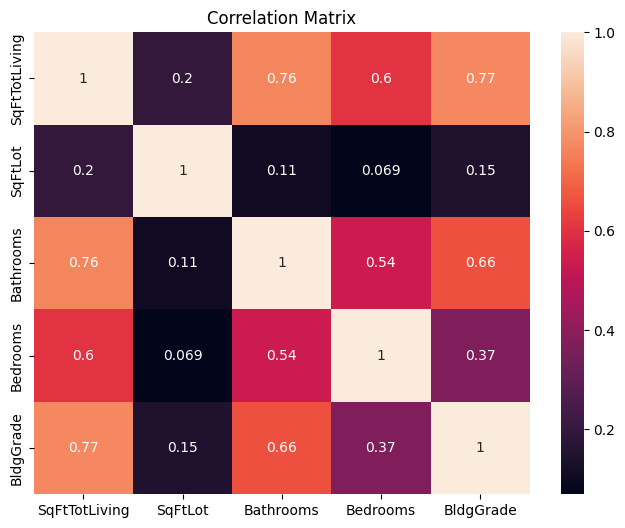

In [28]:
plt.figure(figsize=(8,6))


sns.heatmap(
    correlation,
    annot=True
)


plt.title(
    "Correlation Matrix"
)


plt.show()

# Multicollinearity

Multicollinearity terjadi ketika dua atau lebih variabel prediktor
memiliki hubungan yang sangat kuat.

Dampaknya:

- koefisien regresi menjadi tidak stabil,
- standar error meningkat,
- interpretasi variabel menjadi sulit.

Salah satu cara mendeteksi multicollinearity adalah menggunakan
Variance Inflation Factor (VIF).

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


X = kc_house[
    [
        "SqFtTotLiving",
        "SqFtLot",
        "Bathrooms",
        "Bedrooms",
        "BldgGrade"
    ]
]


vif = pd.DataFrame()


vif["Variable"] = X.columns


vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(
        X.shape[1]
    )
]


vif

,Variable,VIF
0,SqFtTotLiving,17.133055
1,SqFtLot,1.218024
2,Bathrooms,23.226773
3,Bedrooms,19.065439
4,BldgGrade,23.359000


Nilai VIF yang tinggi menunjukkan adanya hubungan kuat antar
variabel prediktor.

Variabel dengan VIF tinggi perlu dianalisis lebih lanjut karena dapat
mengganggu kestabilan model.

# Interaction Terms

Interaction digunakan ketika pengaruh satu variabel terhadap target
bergantung pada variabel lain.

Contoh:

Pengaruh luas rumah terhadap harga mungkin berbeda berdasarkan
kualitas bangunan.

Model tanpa interaction:

Price ~ Area + Grade


Model dengan interaction:

Price ~ Area + Grade + Area*Grade

In [30]:
interaction_model = smf.ols(
    """
    AdjSalePrice ~
    SqFtTotLiving
    + BldgGrade
    + SqFtTotLiving:BldgGrade
    """,
    data=kc_house
).fit()


interaction_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                 1.212e+04
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:43:22   Log-Likelihood:            -3.1314e+05
No. Observations:               22687   AIC:                         6.263e+05
Df Residuals:                   22683   BIC:                         6.263e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                6.255e+05   2.23e+04     28.111      0.000    5.82e+05    6.69e+05
SqFtTotLiving            -418.8431      8.926    -46.922      0.000    -436.340    -401.347
BldgGrade               -4.583e+04   3077.403    -14.893      0.000   -5.19e+04   -3.98e+04
SqFtTotLiving:BldgGrade    69.1935      0.980     70.593      0.000      67.272      71.115
==============================================================================
Omnibus:                    24206.814   Durbin-Watson:                   1.208
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          8991761.180
Skew:                           4.794   Prob(JB):                         0.00
Kurtosis:                     100.058   Cond. No.                     2.81e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.81e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Koefisien interaction menunjukkan apakah hubungan antara satu variabel
dan target berubah berdasarkan nilai variabel lain.

Jika koefisien interaction signifikan, maka efek kedua variabel
tidak berdiri sendiri.

# Regression Diagnostics

Regression diagnostics digunakan untuk mengevaluasi apakah asumsi
regresi terpenuhi.

Model regresi yang baik harus memiliki:

- residual yang menyebar secara acak,
- tidak memiliki outlier ekstrem,
- tidak terdapat pengaruh observasi tertentu yang terlalu besar.


Analisis diagnostik membantu menemukan masalah pada model sebelum
digunakan untuk prediksi.

# Residual Analysis

Residual merupakan selisih antara nilai aktual dan nilai prediksi.

Residual:

Residual = Observasi - Prediksi


Pola residual yang baik adalah tersebar secara acak di sekitar nilai nol.

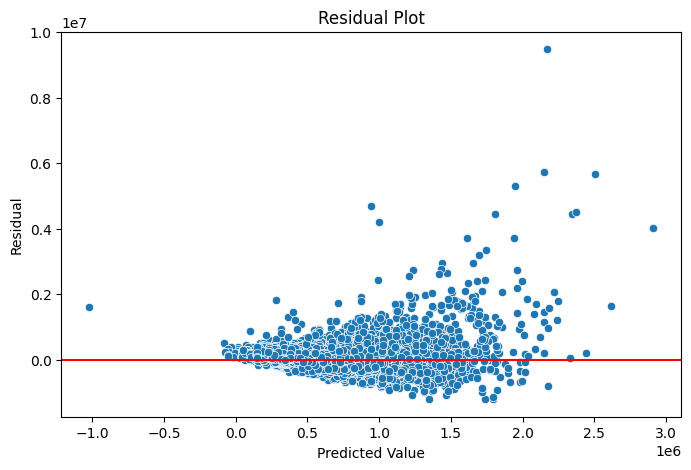

In [31]:
residual = (
    house_model.resid
)


prediction = (
    house_model.fittedvalues
)


plt.figure(figsize=(8,5))


sns.scatterplot(
    x=prediction,
    y=residual
)


plt.axhline(
    0,
    color="red"
)


plt.xlabel(
    "Predicted Value"
)

plt.ylabel(
    "Residual"
)


plt.title(
    "Residual Plot"
)


plt.show()

Jika residual menyebar secara acak di sekitar garis nol,
maka model tidak menunjukkan pola kesalahan tertentu.

Jika terdapat pola tertentu, model kemungkinan belum menangkap
hubungan penting dalam data.

# Outliers

Outlier merupakan observasi yang memiliki nilai berbeda jauh dari
sebagian besar data.

Dalam regresi, outlier dapat memengaruhi:

- nilai koefisien,
- prediksi,
- hasil evaluasi model.

In [32]:
outlier_check = kc_house.copy()


outlier_check["Residual"] = (
    house_model.resid
)


outlier_check[
    [
        "AdjSalePrice",
        "Residual"
    ]
].sort_values(
    by="Residual"
).head()

,AdjSalePrice,Residual
9601,538081.0,-1.199479e+06
10026,602936.0,-1.194509e+06
6517,158793.0,-1.187025e+06
22591,656486.0,-1.137482e+06
14950,151497.0,-1.080081e+06


# Leverage

Leverage menunjukkan seberapa besar pengaruh suatu observasi
terhadap model regresi.

Observasi dengan leverage tinggi memiliki nilai prediktor yang
jauh berbeda dari sebagian besar data.

In [33]:
influence = (
    house_model
    .get_influence()
)


leverage = (
    influence.hat_matrix_diag
)


leverage[:10]

array([0.00061088, 0.00027107, 0.00016485, 0.0005805 , 0.00012656,
       0.00029786, 0.00016591, 0.00012497, 0.00021188, 0.00025397])

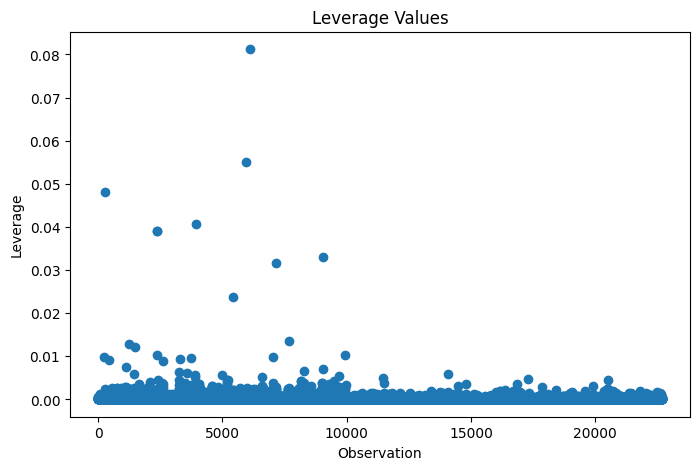

In [34]:
plt.figure(figsize=(8,5))


plt.scatter(
    range(len(leverage)),
    leverage
)


plt.xlabel(
    "Observation"
)

plt.ylabel(
    "Leverage"
)


plt.title(
    "Leverage Values"
)


plt.show()

# Cook's Distance

Cook's Distance digunakan untuk mengukur pengaruh suatu observasi
terhadap keseluruhan model.

Nilai Cook's Distance tinggi menunjukkan bahwa observasi tersebut
memiliki pengaruh besar terhadap hasil regresi.

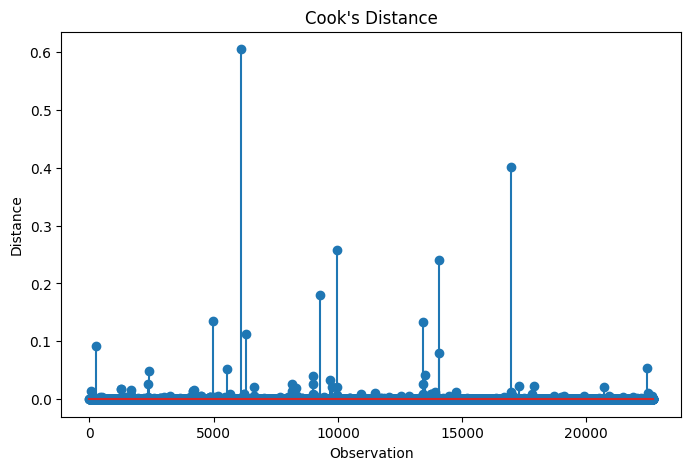

In [35]:
cook_distance = (
    influence
    .cooks_distance[0]
)


plt.figure(figsize=(8,5))


plt.stem(
    cook_distance
)


plt.title(
    "Cook's Distance"
)


plt.xlabel(
    "Observation"
)

plt.ylabel(
    "Distance"
)


plt.show()

# Heteroskedasticity

Heteroskedasticity terjadi ketika variansi residual tidak konstan
pada seluruh rentang prediksi.

Asumsi regresi linear mengharapkan residual memiliki variansi yang
relatif sama.

Dampak heteroskedasticity:

- standar error menjadi tidak akurat,
- pengujian statistik dapat terganggu.

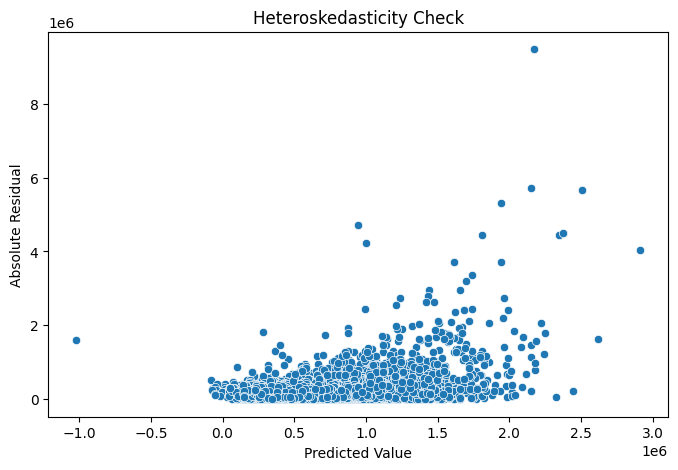

In [36]:
plt.figure(figsize=(8,5))


sns.scatterplot(
    x=house_model.fittedvalues,
    y=np.abs(house_model.resid)
)


plt.xlabel(
    "Predicted Value"
)

plt.ylabel(
    "Absolute Residual"
)


plt.title(
    "Heteroskedasticity Check"
)


plt.show()

# Polynomial Regression

Tidak semua hubungan antara variabel berbentuk garis lurus.

Polynomial regression digunakan ketika hubungan antara predictor dan
response berbentuk kurva.

Model:

Y = β0 + β1X + β2X² + ε

In [37]:
poly_data = kc_house[
    [
        "SqFtTotLiving",
        "AdjSalePrice"
    ]
].copy()


poly_data["SqFt2"] = (
    poly_data["SqFtTotLiving"] ** 2
)

In [39]:
poly_model = smf.ols(
    """
    AdjSalePrice ~
    SqFtTotLiving
    + SqFt2
    """,
    data=poly_data
).fit()


poly_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                 1.368e+04
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:45:52   Log-Likelihood:            -3.1502e+05
No. Observations:               22687   AIC:                         6.300e+05
Df Residuals:                   22684   BIC:                         6.301e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      3.159e+05   7699.120     41.036      0.000    3.01e+05    3.31e+05
SqFtTotLiving   -24.9680      5.951     -4.196      0.000     -36.632     -13.304
SqFt2             0.0584      0.001     56.370      0.000       0.056       0.060
==============================================================================
Omnibus:                    22533.144   Durbin-Watson:                   1.246
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          6294646.548
Skew:                           4.287   Prob(JB):                         0.00
Kurtosis:                      84.151   Cond. No.                     3.29e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.29e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

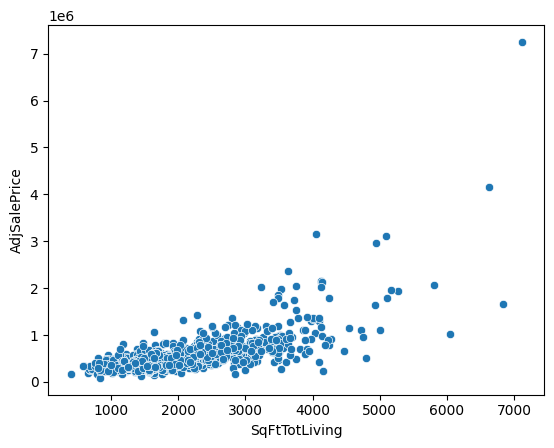

In [40]:
sample_poly = poly_data.sample(
    1000,
    random_state=42
)


sns.scatterplot(
    data=sample_poly,
    x="SqFtTotLiving",
    y="AdjSalePrice"
)


plt.show()

# Splines

Spline regression merupakan metode yang membagi rentang predictor
menjadi beberapa bagian dan membuat model pada setiap bagian.

Keuntungan spline:

- lebih fleksibel dibanding regresi linear,
- mampu menangkap pola non-linear.

In [41]:
pip install patsy

You should consider upgrading via the 'd:\TELKOM\Semester 7\DL\Tugas 1\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [42]:
from patsy import dmatrix


spline = dmatrix(
    "bs(SqFtTotLiving, df=5)",
    data=kc_house,
    return_type="dataframe"
)


spline.head()

,Intercept,"bs(SqFtTotLiving, df=5)[0]","bs(SqFtTotLiving, df=5)[1]","bs(SqFtTotLiving, df=5)[2]","bs(SqFtTotLiving, df=5)[3]","bs(SqFtTotLiving, df=5)[4]"
1,1.0,0.000000,0.723572,0.267321,0.009106,0.000002
2,1.0,0.000000,0.423451,0.465290,0.106040,0.005219
3,1.0,0.005155,0.809389,0.183625,0.001831,0.000000
4,1.0,0.000000,0.534684,0.409154,0.054949,0.001213
5,1.0,0.072751,0.825996,0.101207,0.000045,0.000000


# Generalized Additive Models

GAM merupakan pengembangan regresi yang memungkinkan setiap
prediktor memiliki hubungan non-linear terhadap target.

Model:

Y = β0 + f1(X1) + f2(X2) + ε


GAM menggabungkan fleksibilitas model non-linear dengan
interpretasi regresi.

In [43]:
pip install pygam

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\TELKOM\Semester 7\DL\Tugas 1\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [44]:
from pygam import LinearGAM, s


X = kc_house[
    [
        "SqFtTotLiving"
    ]
]


y = kc_house[
    "AdjSalePrice"
]


gam = LinearGAM(
    s(0)
).fit(
    X,
    y
)


gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     13.8573
Link Function:                     IdentityLink Log Likelihood:                               -586089.7527
Number of Samples:                        22687 AIC:                                          1172209.2198
                                                AICc:                                         1172209.2406
                                                GCV:                                      66196136353.5856
                                                Scale:                                    66123361462.1768
                                                Pseudo R-Squared:                                   0.5551
Feature Function                  Lam

C:\Users\Hp\AppData\Local\Temp\ipykernel_14940\3902072109.py:24: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


# Kesimpulan Chapter 4

Chapter 4 membahas penggunaan regression untuk menjelaskan hubungan
antar variabel dan melakukan prediksi.

Konsep utama:

1. Simple Linear Regression digunakan untuk satu predictor.
2. Multiple Regression menggunakan beberapa predictor.
3. Model assessment digunakan untuk mengevaluasi performa model.
4. Cross validation menguji kemampuan model pada data baru.
5. AIC dan BIC digunakan untuk memilih model.
6. Factor variable digunakan untuk data kategorikal.
7. Multicollinearity diperiksa melalui hubungan antar predictor.
8. Interaction digunakan untuk melihat efek gabungan variabel.
9. Regression diagnostics digunakan untuk mengevaluasi asumsi model.
10. Polynomial, spline, dan GAM digunakan untuk hubungan non-linear.

Regression menjadi salah satu metode utama dalam machine learning
untuk memahami pola data dan membuat prediksi.